In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
import sys
sys.path.append(r'C:\Users\Arthur Zhou\GitHub\aps360_project\src')
from data.data_utils import load_data
from data.tem_beta import MLPDataset

In [3]:
val_loss = np.load(os.path.join("../src/train/gnn/output_enc", "train_loss.npy"))

### Train loss

In [4]:
def plot_loss_curves(output_dir, c,label=None, ax=None, ):
    train_loss = np.load(os.path.join(output_dir, "train_loss.npy"))
    val_loss = np.load(os.path.join(output_dir, "val_loss.npy"))

    c_ = [None, None]
    if len(c) == 1:
        c_ = [c[0], c[0]]
    else:
        c_ = [c[0], c[1]]
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5))

    epochs = np.arange(1, len(train_loss) + 1)
    prefix = f"{label} " if label else ""
    ax.plot(epochs, train_loss, label=f"{prefix}train", color=c_[0] if c_ else None,)
    ax.plot(epochs, val_loss, label=f"{prefix}val", linestyle="--",color=c_[1] if c_ else None,)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (MSE)")
    ax.set_title("Training Curves")
    ax.legend()

    return train_loss, val_loss


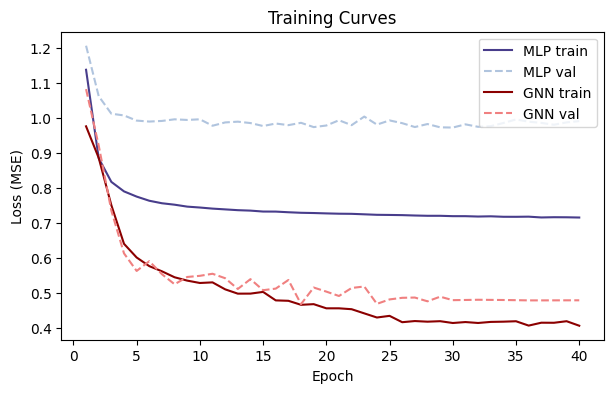

In [12]:
fig, ax = plt.subplots(figsize=(7,4 ))
plot_loss_curves("../src/train/base/output_final", label="MLP", ax=ax, c=['darkslateblue', 'lightsteelblue'])
plot_loss_curves("../src/train/gnn/hp_search/trial_06_seed1012", label="GNN", ax=ax, c=['darkred', 'lightcoral'])
plt.show()


### Look at results


In [5]:
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:.4f}')


def load_inference_results(output_dir, split="test"):
    results_df = pd.read_csv(os.path.join(output_dir, f"{split}_predictions.csv"))
    with open(os.path.join(output_dir, f"{split}_summary.json")) as f:
        summary = json.load(f)
    return results_df, summary
def compute_metrics(results_df) -> dict:
    """
    metrics on the unscaled fitness values.
    R2: regression fit
    Pearson: correlation coef linear
    Spearman: monotonic relationship
    """
    y_true = results_df["target_original"]
    y_pred = results_df["prediction_original"]
    residuals = y_pred - y_true
    
    def get_mets(residuals, y_true):
        rmse = np.sqrt((residuals ** 2).mean())
        rmsestd = np.sqrt((residuals ** 2).std())
        mae = residuals.abs().mean()
        mae_std = residuals.abs().std()
        mse = (residuals ** 2).mean()
        msestd = (residuals ** 2).std()
        ss_res = (residuals ** 2).sum()
        ss_tot = ((y_true - y_true.mean()) ** 2).sum()
        r2 = 1 - ss_res / ss_tot
        return rmse, rmsestd, mae, mae_std, mse, msestd, r2
    
    rmse, rmsestd, mae, mae_std, mse, msestd, r2 = get_mets(residuals, y_true)
    
    fit_0_mask = (y_true <1)
    y_true_no_0 = y_true[~fit_0_mask]
    y_pred_no_0 = y_pred[~fit_0_mask]
    rmse_no_0, rmsestd_no_0, mae_no_0, mae_std_no_0, mse_no_0, msestd_no_0, r2_no_0 = get_mets(y_pred_no_0 - y_true_no_0, y_true_no_0)


    return {
        "RMSE": rmse,
        "RMSE_STD": rmsestd,
        "MAE": mae,
        "MAE_STD": mae_std,
        "MSE": mse,
        "MSE_STD": msestd,
        "R2": r2,
        "RMSE_NO_0": rmse_no_0,
        "RMSE_STD_NO_0": rmsestd_no_0,
        "MAE_NO_0": mae_no_0,
        "MAE_STD_NO_0": mae_std_no_0,
        "MSE_NO_0": mse_no_0,
        "MSE_STD_NO_0": msestd_no_0,
        "R2_NO_0": r2_no_0,
        "Pearson_r": y_true.corr(y_pred, method="pearson"), # across all smaples
        "Spearman_rho": y_true.corr(y_pred, method="spearman"),
        "Pearson_r_no_0": y_true_no_0.corr(y_pred_no_0, method="pearson"), # across all smaples
        "Spearman_rho_no_0": y_true_no_0.corr(y_pred_no_0, method="spearman"),
    }

def plot_parity(results_df, title="", ax=None, color=None, label=None, lims=None):
    """
    plot pred vs actual fit (unscaled)

    color/label: keep one colour per MODEL across every figure, so the same colour never
        means two different things. Leave unset for the old default-blue behaviour.
    lims: shared axis limits. Pass the SAME lims to every panel that is meant to be
        compared - with per-panel limits the model whose predictions spray wider simply
        gets a wider axis, and its larger errors end up looking the same size as the
        other model's smaller ones.
    """
    y_true = results_df["target_original"].to_numpy()
    y_pred = results_df["prediction_original"].to_numpy()

    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))

    if lims is None:
        lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, color="gray", linestyle="--", linewidth=1,)
    ax.scatter(y_true, y_pred, alpha=0.4, s=15, edgecolor="none", color=color, label=label)
    ax.set_xlabel("Actual fitness")
    ax.set_ylabel("Predicted fitness")
    ax.set_title(title)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    # only draw a legend when something is actually labelled, otherwise matplotlib warns
    if ax.get_legend_handles_labels()[1]:
        ax.legend()

    return ax

def plot_label_dis(results_df, title="", ax=None):
    y_true = results_df["target_original"].to_numpy()
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))
    ax.hist(y_true, bins=50, alpha=0.7, color="lightsteelblue", edgecolor="grey")
    ax.set_xlabel("GT fitness")
    ax.set_ylabel("Count")
    ax.set_title(title)

In [7]:
plot_label_dis(results_df, title=f"Label Distribution (n={summary['n_samples']})

SyntaxError: unterminated string literal (detected at line 1) (4156548578.py, line 1)

In [55]:
results_df[results_df["target_original"] >= 1].shape

(131, 4)

C:\Users\Arthur Zhou\AppData\Local\Temp\ipykernel_47748\2068675570.py:86: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
C:\Users\Arthur Zhou\AppData\Local\Temp\ipykernel_47748\2068675570.py:86: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


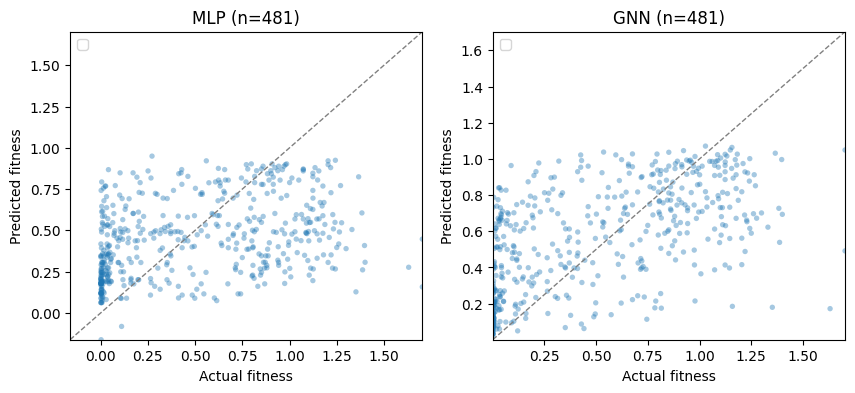

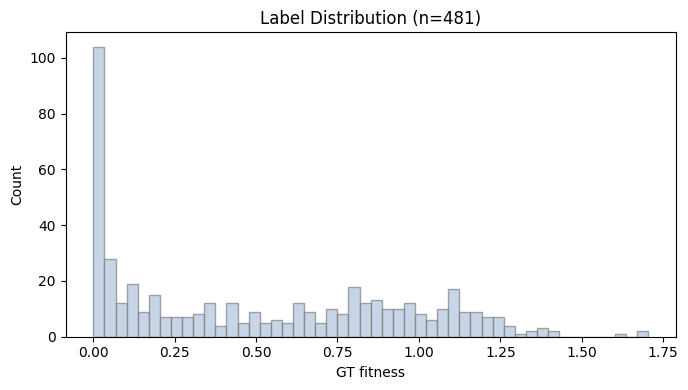

,RMSE,RMSE_STD,MAE,MAE_STD,MSE,MSE_STD,R2,RMSE_NO_0,RMSE_STD_NO_0,MAE_NO_0,MAE_STD_NO_0,MSE_NO_0,MSE_STD_NO_0,R2_NO_0,Pearson_r,Spearman_rho,Pearson_r_no_0,Spearman_rho_no_0,"loss (MSE, normalized)"
MLP,0.423,0.504,0.342,0.250,0.179,0.254,0.084,0.690,0.643,0.634,0.273,0.475,0.414,-24.670,0.360,0.416,-0.236,-0.131,0.900
GNN,0.364,0.449,0.285,0.227,0.133,0.202,0.321,0.489,0.583,0.403,0.280,0.240,0.340,-11.934,0.584,0.626,-0.208,-0.144,0.668


In [14]:
model_dirs = {
    "MLP": "../src/train/base/inference",
    "GNN": "../src/train/gnn/output_final/single",
}

metrics_rows = {}
fig, axes = plt.subplots(1, len(model_dirs), figsize=(5 * len(model_dirs), 4))
fig2, ax2 = plt.subplots(figsize=(7, 4))
if len(model_dirs) == 1:
    axes = [axes]
    axes2 = [ax2]

for ax, (name, output_dir) in zip(axes, model_dirs.items()):
    results_df, summary = load_inference_results(output_dir, split="test")
    metrics = compute_metrics(results_df)
    metrics["loss (MSE, normalized)"] = summary["loss"]
    metrics_rows[name] = metrics
    plot_parity(results_df, title=f"{name} (n={summary['n_samples']})", ax=ax)
plot_label_dis(results_df, title=f"Label Distribution (n={summary['n_samples']})", ax=ax2)

plt.tight_layout()
#plt.savefig("parity_plots.png", dpi=200, bbox_inches="tight")
plt.show()

metrics_df = pd.DataFrame(metrics_rows).T

styled_metrics = metrics_df.style.format("{:.3f}").set_table_styles([
    {'selector': 'th, td', 'props': [('padding', '2px 6px'), ('font-size', '9pt'), ('line-height', '1.1')]}
])

display(styled_metrics)


### Double mutants (held out)
Regenerate with:

```
python src/train/gnn/infer.py  --processed_dms src/data/processed/both \
  --config src/train/gnn/hp_search/best_config.json \
  --model_path src/train/gnn/output_final/best_model.pt \
  --split double --seed 1012 --output_dir src/train/gnn/output_final/double

python src/train/base/infer.py --processed_dms src/data/processed/both \
  --config src/train/gnn/hp_search/best_config.json \
  --model_path src/train/base/output_final/best_model.pt \
  --split double --output_dir src/train/base/output_final/double
```

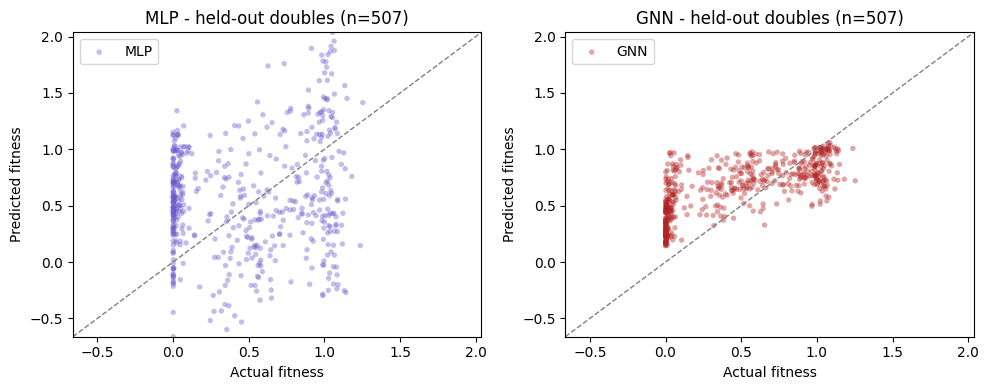

,RMSE,RMSE_STD,MAE,MAE_STD,MSE,MSE_STD,R2,RMSE_NO_0,RMSE_STD_NO_0,MAE_NO_0,MAE_STD_NO_0,MSE_NO_0,MSE_STD_NO_0,R2_NO_0,Pearson_r,Spearman_rho,Pearson_r_no_0,Spearman_rho_no_0,"loss (MSE, normalized)"
MLP,0.596,0.611,0.511,0.306,0.355,0.373,-1.041,0.713,0.710,0.617,0.359,0.508,0.504,-211.479,0.178,0.118,-0.128,-0.178,1.784
GNN,0.349,0.395,0.287,0.199,0.122,0.156,0.300,0.258,0.275,0.212,0.148,0.067,0.075,-26.877,0.698,0.725,0.140,0.209,0.612


In [10]:

MODEL_COLORS = {"MLP": "#6A5ACD", "GNN": "#B22222"}

# {model: {split label: (output_dir, the split name infer.py saved the files under)}}
SPLIT_DIRS = {
    "MLP": {"single":   ("../src/train/base/output_final/inference", "test"),
            "double": ("../src/train/base/output_final/double", "double")},
    "GNN": {"single":   ("../src/train/gnn/output_final/single", "test"),
            "double": ("../src/train/gnn/output_final/double", "double")},
}

SPLIT_DIRS = {
    "MLP": {"single":   ("../src/train/base/output_random/inference", "random"),
            "double": ("../src/train/base/output_final/double", "double")},
    "GNN": {"single":   ("../src/train/gnn/output_nostruct/inference", "random"),
            "double": ("../src/train/gnn/output_final/double", "double")},
}

double_results = {}
for name, splits in SPLIT_DIRS.items():
    output_dir, file_split = splits["double"] 
    double_results[name] = load_inference_results(output_dir, split=file_split)

# one set of limits for every panel - see plot_parity's docstring for why this matters
_vals = np.concatenate([df[["target_original", "prediction_original"]].to_numpy().ravel()
                        for df, _ in double_results.values()])
shared_lims = [_vals.min(), _vals.max()]

double_rows = {}
fig, axes = plt.subplots(1, len(SPLIT_DIRS), figsize=(5 * len(SPLIT_DIRS), 4))
for ax, (name, (results_df, summary)) in zip(np.atleast_1d(axes), double_results.items()):
    metrics = compute_metrics(results_df)
    metrics["loss (MSE, normalized)"] = summary["loss"]
    double_rows[name] = metrics
    plot_parity(results_df, title=f"{name} - held-out doubles (n={summary['n_samples']})",
                ax=ax, color=MODEL_COLORS[name], label=name, lims=shared_lims)

plt.tight_layout()
plt.show()

double_metrics_df = pd.DataFrame(double_rows).T
display(double_metrics_df.style.format("{:.3f}").set_table_styles([
    {'selector': 'th, td', 'props': [('padding', '2px 6px'), ('font-size', '9pt'), ('line-height', '1.1')]}
]))

model,split,n,spearman,pearson,mse,mse_vs_mean
MLP,single,481,0.416,0.360,0.900,0.916
MLP,double,507,0.118,0.178,1.784,2.041
GNN,single,481,0.626,0.584,0.668,0.679
GNN,double,507,0.725,0.698,0.612,0.700


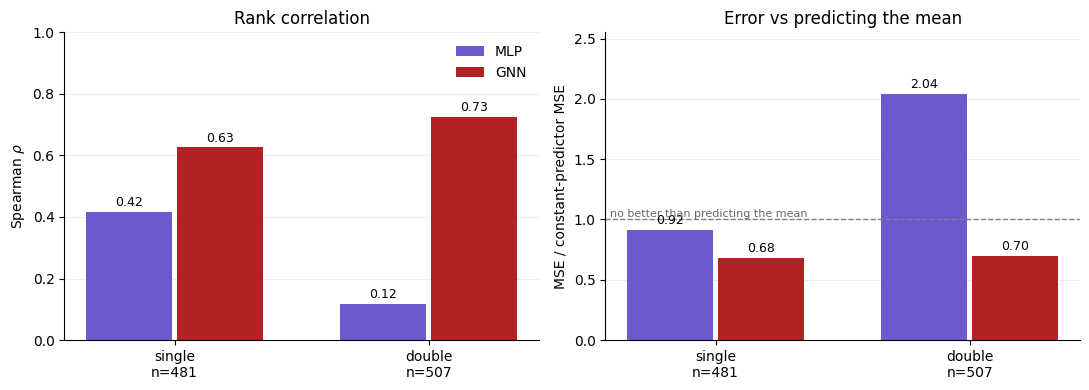

In [30]:
def load_split_metrics(split_dirs) -> pd.DataFrame:
    """
    One row per (model, split), read straight from the *_summary.json each infer.py writes.

    'mse_vs_mean' is the loss divided by the constant-predictor loss ON THE SAME ROWS. Raw
    MSE is not comparable across splits because each split has its own label spread; the
    ratio is, and it has a fixed reading - 1.0 is "no better than predicting the mean",
    above 1.0 is worse than that.
    """
    rows = []
    for model, splits in split_dirs.items():
        for split_label, (output_dir, file_split) in splits.items():
            _, s = load_inference_results(output_dir, split=file_split)
            rows.append({"model": model, "split": split_label, "n": s["n_samples"],
                         "spearman": s["spearman_rho"], "pearson": s["pearson_r"],
                         "mse": s["loss"], "mse_vs_mean": s["loss"] / s["baseline_loss"]})
    return pd.DataFrame(rows)


split_metrics = load_split_metrics(SPLIT_DIRS)
display(split_metrics.style.hide(axis="index").format(
    {"spearman": "{:.3f}", "pearson": "{:.3f}", "mse": "{:.3f}", "mse_vs_mean": "{:.3f}"}))

split_labels = list(next(iter(SPLIT_DIRS.values())).keys())
counts = dict(zip(split_metrics["split"], split_metrics["n"]))
x = np.arange(len(split_labels))
width = 0.36

# two measures on different scales -> two panels, never two y-axes on one plot
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
panels = [("spearman", "Rank correlation", r"Spearman $\rho$"),
          ("mse_vs_mean", "Error vs predicting the mean", "MSE / constant-predictor MSE")]

for ax, (col, title, ylabel) in zip(axes, panels):
    for i, model in enumerate(SPLIT_DIRS):
        sub = split_metrics[split_metrics["model"] == model].set_index("split")
        vals = [sub.loc[s, col] for s in split_labels]
        # *0.94 leaves a small gap between the paired bars so they read as two marks
        bars = ax.bar(x + (i - 0.5) * width, vals, width * 0.94,
                      label=model, color=MODEL_COLORS[model])
        ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{s}\nn={counts[s]}" for s in split_labels])
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25, linewidth=0.6)
    ax.set_axisbelow(True)
    if col == "mse_vs_mean":
        ax.axhline(1.0, color="gray", linestyle="--", linewidth=1)
        ax.text(0.01, 1.0, "no better than predicting the mean",
                transform=ax.get_yaxis_transform(), va="bottom", ha="left",
                fontsize=8, color="dimgray")
        ax.set_ylim(0, split_metrics["mse_vs_mean"].max() * 1.25)
    else:
        ax.set_ylim(0, 1.0)

axes[0].legend(frameon=False)
plt.tight_layout()
plt.savefig("split_metrics.png", dpi=200, bbox_inches="tight")
plt.show()

#### Label composition of the splits

What the models are being scored *against* — the balance of dead / reduced / WT-like
variants in each split. This is a property of the labels, not of any model.

Worth checking before reading the metrics: if the double split were mostly dead variants,
a high rank correlation could come from separating dead-vs-alive alone.

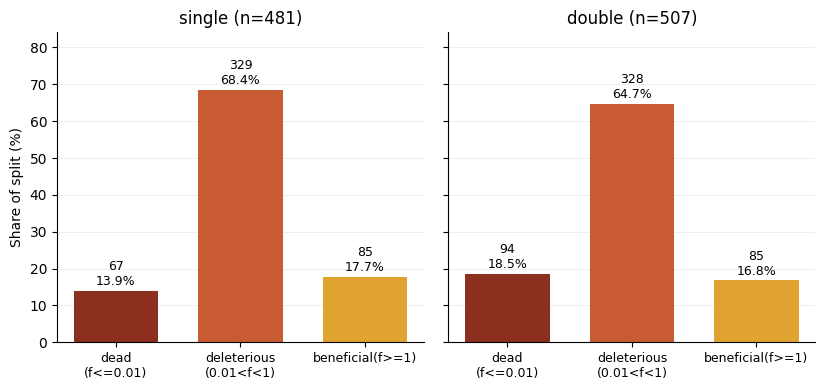

,dead (f<=0.01),deleterious (0.01<f<1),beneficial(f>=1),n
single,67,329,85,481
double,94,328,85,507


In [35]:
# dead -> reduced -> WT-like is an ORDERED severity scale, so the ramp darkens with
# severity instead of using three unrelated hues. Checked against a light background:
# chroma, lightness band and adjacent separation (deutan dE 15.6) all pass. The lightest
# step is low contrast, which is why every bar carries a visible label.
FITNESS_CLASS_COLORS = ["#8C2F1E", "#C85A34", "#E0A32F"]


def fitness_class_names(dead_tol=0.01):
    """Class names, with the tolerance written in so it cannot be misread as f == 0."""
    return [f"dead (f<={dead_tol:g})", f"deleterious ({dead_tol:g}<f<1)", "beneficial(f>=1)"]


def classify_fitness(y, dead_tol=0.01):
    """
    Bin measured fitness into dead / reduced / WT-like.

    There are NO exact zeros in this data - the smallest measured fitness is ~9e-4 - so
    "dead" has to be a tolerance. A literal (y == 0) test matches nothing and silently
    produces an empty class. The default 0.01 sits just past the spike at the bottom of
    the distribution (67 of the 507 doubles fall below 0.002, then the density drops off);
    it is a knob, so re-run with dead_tol=0.002 or 0.05 to see how much any conclusion
    depends on where the line is drawn.

    returns:
        ordered pandas Categorical
    """
    dead, reduced, wt = fitness_class_names(dead_tol)
    y = np.asarray(y, dtype=float)
    labels = np.where(y >= 1.0, wt, np.where(y <= dead_tol, dead, reduced))
    return pd.Categorical(labels, categories=[dead, reduced, wt], ordered=True)


def plot_fitness_classes(results, dead_tol=0.01, axes=None, figsize=None, value_col=None):
    """
    Class composition of the measured fitness LABELS in each split - no predictions involved.

    Bars are share of the split, not raw count, so splits of different size can be compared
    directly; the raw count sits on each bar as well.

    args:
        results: a DataFrame, or {split label: DataFrame} for one panel per split. Reads
            'target_original' when present (an infer.py predictions file), else 'Fitness'
            (a raw dms frame), so it works on both.
        dead_tol: upper bound of the dead class, see classify_fitness
        value_col: force a specific column instead of the auto-detection above
    returns:
        counts: DataFrame indexed by split, one column per class, plus 'n'
    """
    if isinstance(results, pd.DataFrame):
        results = {"": results}
    classes = fitness_class_names(dead_tol)

    counts = {}
    for label, df in results.items():
        col = value_col or ("target_original" if "target_original" in df.columns else "Fitness")
        series = pd.Series(classify_fitness(df[col], dead_tol))
        counts[label] = series.value_counts().reindex(classes).fillna(0).astype(int)
    counts = pd.DataFrame(counts).T[classes]
    counts["n"] = counts.sum(axis=1)

    if axes is None:
        figsize = figsize or (4.2 * len(counts), 4)
        _, axes = plt.subplots(1, len(counts), figsize=figsize, sharey=True)
    axes = np.atleast_1d(axes)

    x = np.arange(len(classes))
    for ax, (label, row) in zip(axes, counts.iterrows()):
        n = row["n"]
        pct = [100 * row[c] / n for c in classes]
        bars = ax.bar(x, pct, 0.68, color=FITNESS_CLASS_COLORS)
        ax.bar_label(bars, labels=[f"{row[c]}\n{p:.1f}%" for c, p in zip(classes, pct)],
                     padding=2, fontsize=9)
        ax.set_xticks(x)
        ax.set_xticklabels([c.replace(" (", "\n(") for c in classes], fontsize=9)
        ax.set_title(f"{label} (n={n})" if label else f"n={n}")
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", alpha=0.25, linewidth=0.6)
        ax.set_axisbelow(True)
        ax.set_ylim(0, max(pct) * 1.3)
    axes[0].set_ylabel("Share of split (%)")
    return counts


# labels are identical for both models on a given split, so read them from either one
label_sets = {label: load_inference_results(*spec)[0]
              for label, spec in SPLIT_DIRS["GNN"].items()}

class_counts = plot_fitness_classes(label_sets)
plt.tight_layout()
plt.show()

display(class_counts)

In [34]:
label_sets['double']['Fitness'].max()

np.float64(1.2533543)

In [15]:
s_df

,Single,Ambler Index,Code,Fitness,Estimated error in fitness,Epistasis,Experiment Sequence
0,1,23,H_26_A,1.2943,0.1750,-111,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...
1,1,23,H_26_C,0.5646,0.0805,-111,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...
2,1,23,H_26_D,1.0992,0.1505,-111,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...
3,1,23,H_26_E,0.9899,0.1965,-111,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...
4,1,23,H_26_F,0.7883,0.2249,-111,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...
...,...,...,...,...,...,...,...
5027,1,285,W_290_R,0.0129,0.0017,-111,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...
5028,1,285,W_290_S,0.0045,0.0006,-111,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...
5029,1,285,W_290_T,0.0037,0.0005,-111,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...
5030,1,285,W_290_V,0.0057,0.0007,-111,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...


In [4]:
mlp_df = pd.read_csv(r'C:\Users\Arthur Zhou\GitHub\aps360_project\src\data\processed\single\dms_processed.csv')
dataset_single = MLPDataset(dms_data=mlp_df, pdb_id='1BTL',)
s_df = dataset_single.dms.copy()
#plot_label_dis(s_df.rename(columns={"Fitness": "target_original"}))

In [9]:
len(s_df[s_df['Fitness'] > 1.0]) / len(s_df['Fitness'])

0.21740858505564387